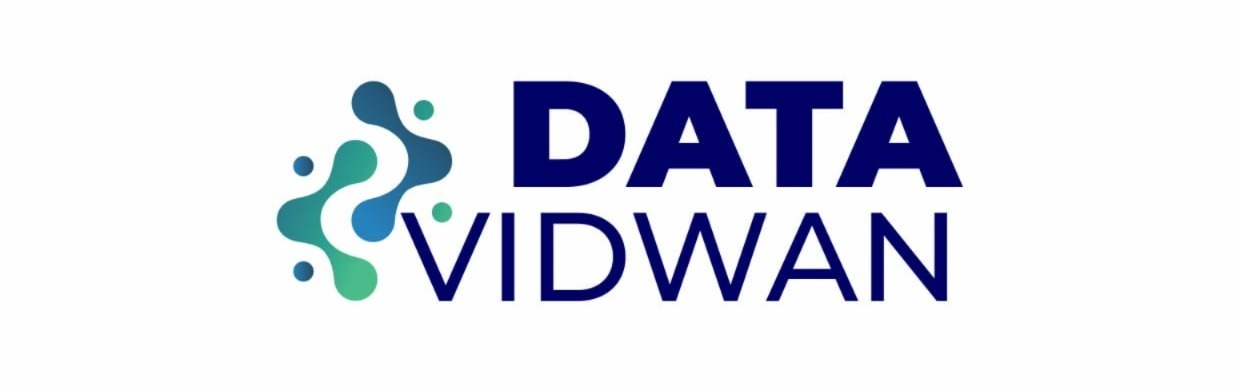

# **What is K-Means ?**

K Means is an unsupervised learning algorithm that groups similar data points into K clusters. It finds patterns in data without using labels.

**Example:**

A supermarket wants to divide customers into groups like low spenders, medium spenders and high spenders. There are no labels in the data. K Means automatically finds groups based on spending patterns.

# **Why is it called K Means**

K represents the number of clusters. Means refers to the average because each cluster center is calculated using the mean of the points.

**Example:**

If you want to divide players into three skill groups based only on their scores, then K is three. For each group, the average score becomes the group center.

# **Where K Means is used**

It is used in customer segmentation, image compression, document grouping and pattern discovery in unlabeled data.

**Example:**

A news website group articles into topics like sports, politics and technology without any manual labels.

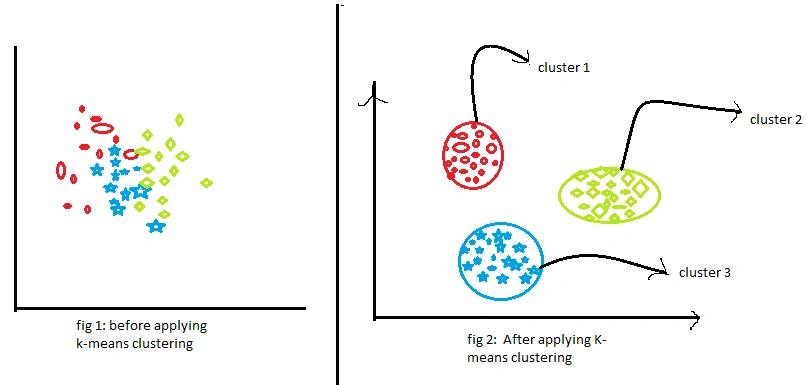

# **How K Means Works**

**Step 1 Choose K**

You decide how many clusters you want before starting. K is always chosen manually.

**Example:**

A school wants to separate students into three performance groups A B and C based on marks. So the school decides K equals three because they need three groups.

**Step 2 Initialize Centroids**

The algorithm randomly picks K points from the dataset as the initial centroids.

**Example**

If K is three for student marks, then three random students are selected. Their marks become the starting group centers.

**Step 3 Assignment Step**

For every data point, the algorithm calculates the distance to each centroid and assigns the point to the nearest one.

**Example**

Suppose a student has 67 marks. If the current three centroids are 40, 60 and 90, the student is closest to 60. So the student is placed in the group whose center is 60.

**Step 4 Update Step**

After assigning all points, the centroid of each cluster is recalculated by taking the mean value of all points in that cluster.

**Example:**

In the group nearest to 60, suppose students have marks 55, 60, 62, 67. The new centroid becomes the average which is 61. This average becomes the new center of that cluster.

**Step 5 Repeat Until Stable**

Assignment and update steps repeat until the centroids stop moving or movement becomes extremely small. Once stable, the clusters are final.

**Example:**

After repeated recalculation, suppose the center becomes 61 and stays 61 in further attempts. This means the group has stabilized and clustering is complete.

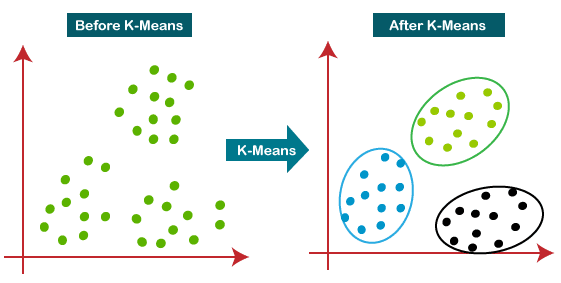

# **Important Concepts Used in K Means**

**Distance Metric**

K Means uses distance to decide closeness. Euclidean  distance is the most common.

**Example**

If you group houses using size and price, a house is placed in the cluster whose centroid is closest in terms of size and price values.

**Random Initializatoin Problem**

Choosing random starting centroids can lead to different cluster results.

**Example**

If three random students with 10 marks, 80 marks and 95 marks are picked as initial centers, groups will form differently compared to when the initial picks were 40, 60 and 90. This shows how initial values change the grouping.

**K Means Plus Plus Initialization**

This method spreads out initial centroids so they are far apart. It produces more consistent results.

**Example**

To group restaurants by cost and rating, K Means Plus Plus chooses starting restaurants that are not similar so the clusters do not overlap.

**Inertia or Within Cluster Sum of Squares**

Inertia measures how tightly points are grouped in a cluster. Lower inertia means better clustering.

**Example**

If you group employees based on working hours and the values inside a cluster are very close like 8, 8.5, 9, 9.2 hours then inertia will be low which means the group is well formed.

**Objective of K Means**

K Means tries to keep data points as close as possible to their centroid. The goal is to minimize the overall distance inside each cluster.

**Example**

If you group athletes based on speed, K Means will try to form groups where the speeds inside each group are tightly packed.

**Convergence**

Convergence means the centroids stop shifting. Once convergence happens, the algorithm ends.

**Example**

If product prices inside a cluster stabilize around a certain average that no longer changes, the cluster is finalized.



# **How to Select the Best K**

**1. Elbow Method**

- K Means requires us to choose how many clusters (K) we want.
- The problem is that we do not know the correct K before running the algorithm.
Choosing a wrong K will create bad clusters.
- So we need a method to help us find the best number of clusters.
- The Elbow Method checks how the inertia (cluster compactness) changes when we try different values of K.
- Inertia always decreases when K increases, but only up to a point. After that point, the improvement becomes very small.
- The place where the improvement suddenly drops and becomes slow is called the elbow point.

**Example**

A bank wants to group customers based on spending behavior. They try different values of K:

- K = 1 → Poor grouping
- K = 2 → Large improvement
- K = 3 → Large improvement
- K = 4 → Small improvement
- K = 5 → Very small improvement

Here, K = 3 or 4 is the best choice because improvement becomes very small after that.
This is exactly what the elbow method helps us identify.

**2. Silhouette Score**

It measures how well separated and compact the clusters are. Higher score means better clustering.

**Example**

If silhouette score is highest for four clusters in a restaurant dataset, then K equals four is the correct choice for grouping restaurants.

# **Problem Statement**

A financial company wants to understand different types of credit card users based on their spending behavior, payment patterns and credit usage. Since the customers are not labeled into any category, the company needs an unsupervised method to automatically discover natural customer segments. The goal is to apply K Means Clustering to group customers into meaningful segments so the company can design targeted marketing strategies, personalized offers and better credit risk management.

# **Library**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

**silhouette_score**

Used to measure how well the clusters are formed and to help decide the best value of K.

**PCA**

Used to reduce high dimensional data to 2D or 3D so we can visualize the clusters.

# **Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Credit_Card_Dataset.csv to Credit_Card_Dataset.csv


In [3]:
# Load the dataset
df = pd.read_csv("Credit_Card_Dataset.csv")

# Show first 5 rows
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# **Data Understanding**

In [4]:
# Shape of the dataset
print("Shape of dataset:", df.shape)

# Basic information about columns
print("\nDataset Info:")
df.info()

# Check missing values
print("\nMissing Values:")
df.isnull().sum()

Shape of dataset: (8950, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX         

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


# **Handle Missing Values**

In [5]:
df = df.copy()   # ensure no view issues

df.fillna({
    'CREDIT_LIMIT': df['CREDIT_LIMIT'].median(),
    'MINIMUM_PAYMENTS': df['MINIMUM_PAYMENTS'].median()
}, inplace=True)

df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


# **Prepare Data for K Means**

Before clustering, we must do two important things:

**1. Drop CUST_ID**

This column is not useful for clustering because it is just an identifier.

**2. Scale the data**

K Means is a distance-based algorithm.
If we do not scale the data, features like BALANCE (thousands) will dominate features like FREQUENCY (0 to 1). So scaling is mandatory.

In [6]:
# Make a copy
data = df.copy()

# Drop the non-numeric ID column
data.drop(columns=['CUST_ID'], inplace=True)

# Apply Standard Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Convert scaled output back to DataFrame for clarity
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


- Removes CUST_ID safely.
- StandardScaler(): Converts all columns to similar scale: mean 0, standard deviation 1.

In [7]:
print("Mean of each column:\n", scaled_df.mean())
print("\nStandard Deviation of each column:\n", scaled_df.std())

Mean of each column:
 BALANCE                            -2.540488e-17
BALANCE_FREQUENCY                   1.587805e-16
PURCHASES                           3.175610e-18
ONEOFF_PURCHASES                   -6.033659e-17
INSTALLMENTS_PURCHASES              3.175610e-17
CASH_ADVANCE                       -6.351220e-18
PURCHASES_FREQUENCY                 9.328354e-17
ONEOFF_PURCHASES_FREQUENCY          1.905366e-17
PURCHASES_INSTALLMENTS_FREQUENCY    5.716098e-17
CASH_ADVANCE_FREQUENCY             -1.595744e-16
CASH_ADVANCE_TRX                   -1.746585e-17
PURCHASES_TRX                      -1.905366e-17
CREDIT_LIMIT                        1.016195e-16
PAYMENTS                           -2.540488e-17
MINIMUM_PAYMENTS                    1.270244e-17
PRC_FULL_PAYMENT                   -9.526830e-18
TENURE                              2.921561e-16
dtype: float64

Standard Deviation of each column:
 BALANCE                             1.000056
BALANCE_FREQUENCY                   1.000056
PUR

we will find the best number of clusters (K) using:

1. Elbow Method
2. Silhouette Score

Let's start with Elbow Method.

**1. Elbow Method**

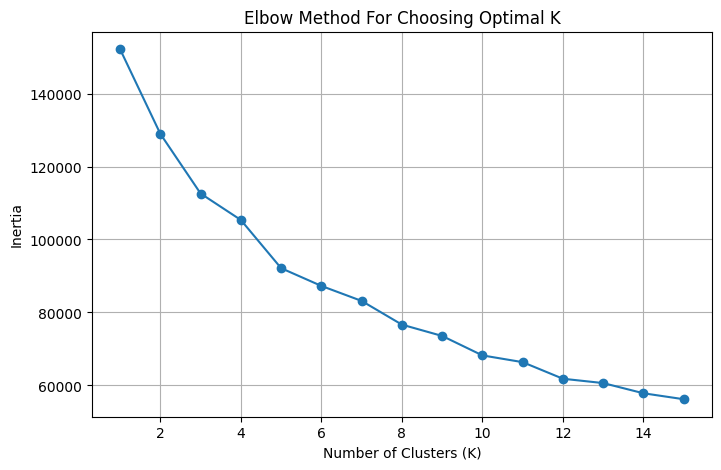

In [8]:
inertia_values = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 16), inertia_values, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method For Choosing Optimal K")
plt.grid(True)
plt.show()

Look at how inertia is decreasing as K increases.

- From K = 1 to K = 5
- The drop in inertia is very large.
- This means adding clusters is improving the grouping a lot.

- From K = 5 to K = 7
- The drop becomes smaller.
- The improvement slows down.

From K = 8 onward
The curve becomes almost flat.
Adding more clusters does not improve the result much.

**Where is the Elbow?**

The elbow point is where the curve changes shape
big drop → small drop.

In your graph, that point is around:

K = 4 or K = 5

These are the most meaningful choices for clustering.

**2. Silhouette Score Code**

Silhouette Score measures how well each point fits into its cluster compared to other clusters.

Score range
- -1 to 1
Higher score means better clustering.

If Silhouette Score is high
Clusters are well separated

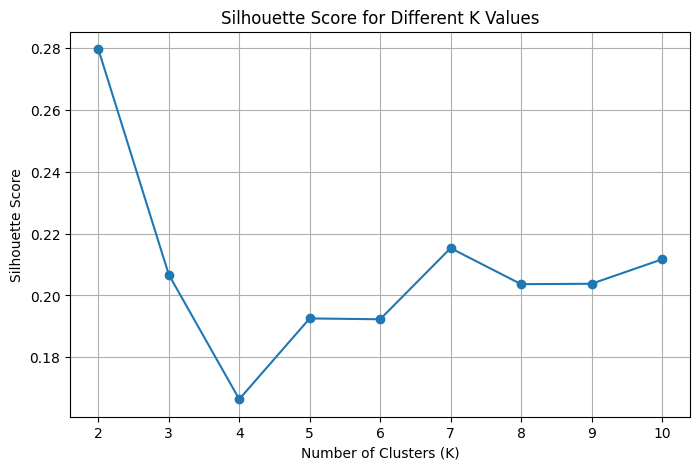

In [9]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):   # silhouette cannot be used for k = 1
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    score = silhouette_score(scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.grid(True)
plt.show()

**Silhouette Score Interpretation**

The goal is to find the highest score, because higher score means better clustering.

Based on your graph:

**Silhouette Scores:**

- K = 2 → 0.28 → highest
- K = 3 → 0.21
- K = 4 → 0.17
- K = 5 → 0.19
- K = 6 → 0.19
- K = 7 → 0.216
- K = 8 → 0.204
- K = 9 → 0.205
- K = 10 → 0.212

**Best K According to Silhouette Score = 2**

This score is clearly the highest.

**Why is K=2 so good?**

Because the dataset naturally has:

High spenders vs Low spenders
or
High credit usage vs Low credit usage

Many financial datasets show two main customer groups




**Final Decision**

When both methods give different answers:

- Elbow Method → tells how many clusters give meaningful improvement
- Silhouette Score → tells which K gives clean separation

In real-world credit card segmentation, we often prefer more than 2 segments, because:

Companies want multiple customer groups Example
- Low spenders
- Medium spenders
- High spenders
- Cash-advance users
- Installment heavy users

So we combine both results:

Practical choice for customer segmentation = K = 4

because this is the best balance between:

- Meaningful business segmentation
- Mathematical stability
- Elbow curve suggestion

# **K Means with K = 4**

In [10]:
# K Means with K = 4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(scaled_df)

# Adding cluster labels to original dataframe
df['Cluster'] = kmeans.labels_

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,3
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


In [11]:
df['Cluster'].value_counts()

,count
Cluster,
3,3368
2,3118
1,1487
0,977


**What This Means**

The clusters are not equal, and that is completely normal.

In real financial datasets, customer behavior is not evenly spread. Some patterns are very common, and some patterns are rare.

**Example**

- Many people are low spenders → big cluster
- Few people are very high spenders → small cluster

This pattern also appears in your data.

# **PCA Visualization**

**Before Clustering**

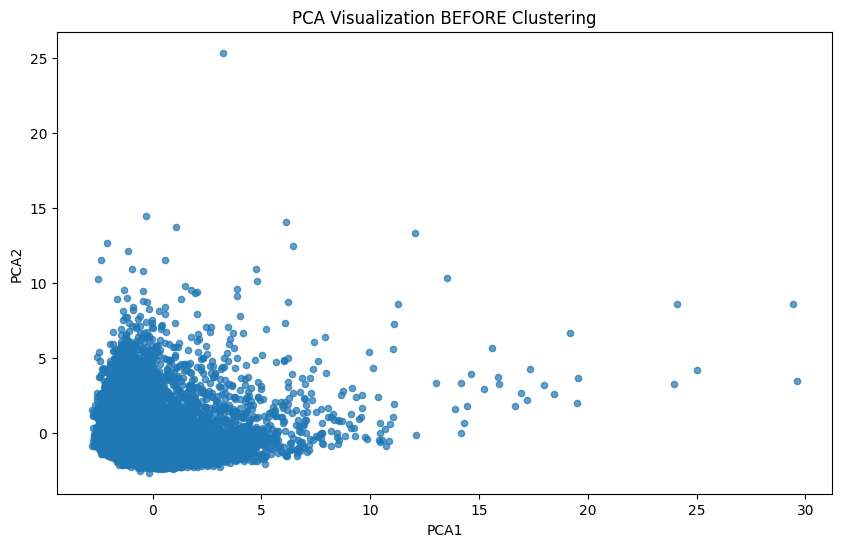

In [ ]:
# PCA before clustering (no cluster labels)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

plt.figure(figsize=(10,6))
plt.scatter(pca_components[:,0], pca_components[:,1], s=20, alpha=0.7)
plt.title("PCA Visualization BEFORE Clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

- pca_components[:,0] → first PCA component values (PC1)
- pca_components[:,1] → second PCA component values (PC2)

- X-axis = PC1
- Y-axis = PC2

**After Clustering**

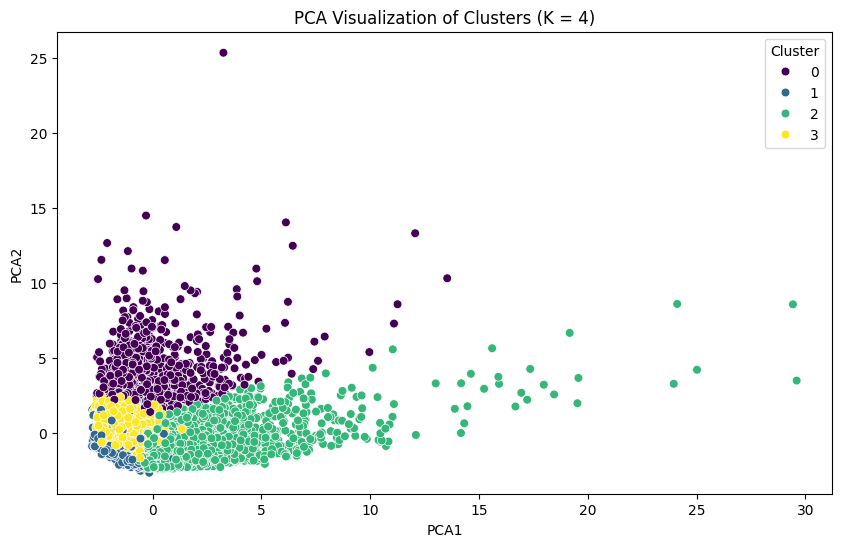

In [12]:
# Apply PCA to reduce data to 2 components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

# Convert to DataFrame
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df['Cluster']

# Plot PCA clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster',
                palette='viridis', data=pca_df, s=40)
plt.title("PCA Visualization of Clusters (K = 4)")
plt.show()

# **Cluster Interpretation**

In [15]:
cluster_profile = df.drop(columns=['CUST_ID']).groupby('Cluster').mean()
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,5010.394668,0.966663,716.017789,450.235875,265.885977,5065.974690,0.327150,0.160632,0.218675,0.508502,15.770727,10.345957,8208.653578,4173.817878,2214.536286,0.040025,11.416581
1,108.430006,0.412096,350.247868,190.521089,160.197189,299.482324,0.320591,0.072760,0.234912,0.035072,0.730330,4.812374,3632.112008,1036.853064,172.183554,0.253704,11.217888
2,1253.817942,0.974758,2182.022178,1241.768493,940.517248,234.564524,0.928413,0.390217,0.748106,0.041717,0.807569,32.727389,5121.987288,2148.583305,778.937414,0.282970,11.729314
3,1495.324927,0.966467,283.482824,210.004454,73.794186,782.285268,0.207097,0.098032,0.108717,0.157514,2.988420,3.665380,3216.349960,947.961448,805.685810,0.022886,11.482482


df.drop(columns=['CUST_ID'])
- Removes the string ID column so only numeric columns remain.

.groupby('Cluster').mean()
- Now pandas calculates the average values for each cluster without errors.

| Cluster | Type of Customer                     | Behavior Summary                                             |
| ------- | ------------------------------------ | ------------------------------------------------------------ |
| **0**   | Heavy Cash Advance Users             | High balance, very high cash advance, medium purchases       |
| **1**   | Low Spenders                         | Low balance, low credit limit, low purchases, safe customers |
| **2**   | High Spenders                        | High purchases, frequent shoppers, best customer group       |
| **3**   | Low Spending + Moderate Cash Advance | Medium balance, low purchases, occasional cash advance       |


**Bar Chart – Compare BALANCE of Clusters**

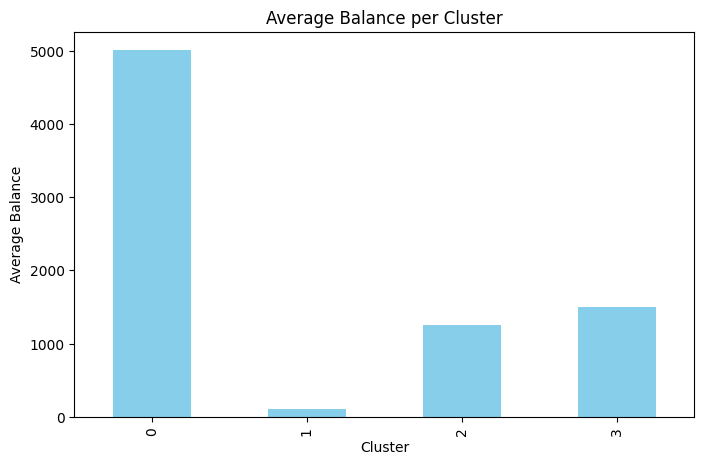

In [16]:
plt.figure(figsize=(8,5))
cluster_profile['BALANCE'].plot(kind='bar', color='skyblue')
plt.title("Average Balance per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Balance")
plt.show()

**Bar Chart – Compare PURCHASES of Clusters**

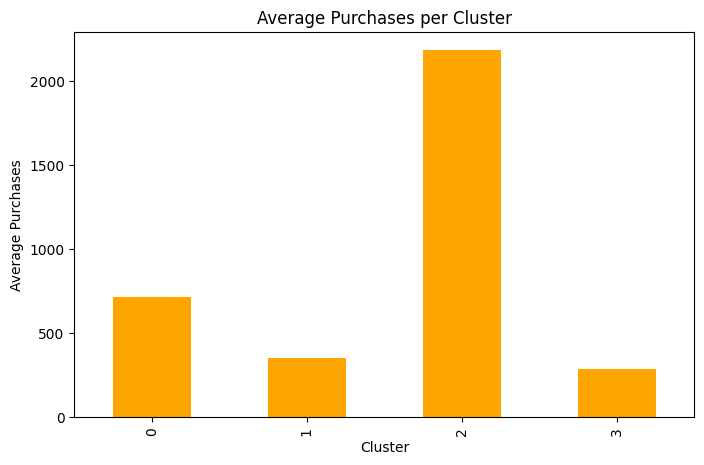

In [17]:
plt.figure(figsize=(8,5))
cluster_profile['PURCHASES'].plot(kind='bar', color='orange')
plt.title("Average Purchases per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Purchases")
plt.show()

**Bar Chart – Compare CASH ADVANCE of Clusters**

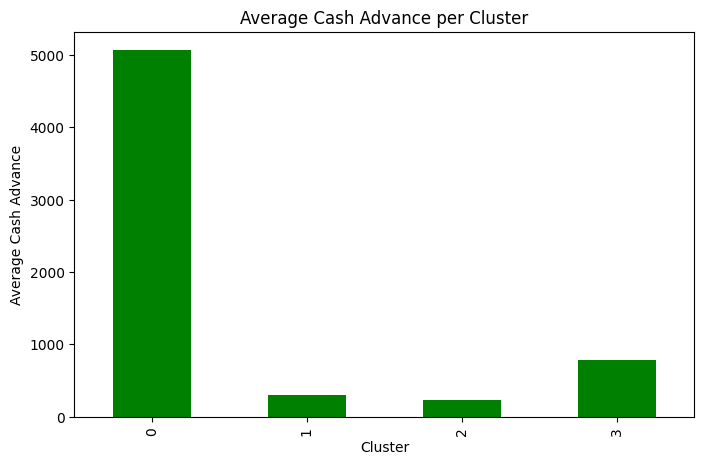

In [18]:
plt.figure(figsize=(8,5))
cluster_profile['CASH_ADVANCE'].plot(kind='bar', color='green')
plt.title("Average Cash Advance per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Cash Advance")
plt.show()

**Bar Chart – Compare CREDIT LIMIT of Clusters**

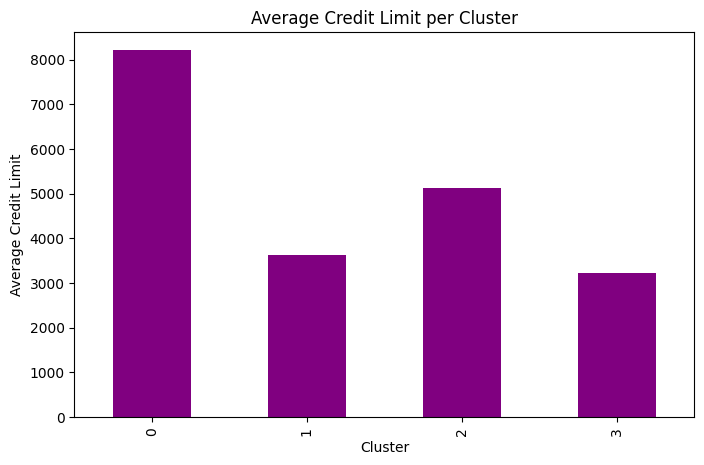

In [19]:
plt.figure(figsize=(8,5))
cluster_profile['CREDIT_LIMIT'].plot(kind='bar', color='purple')
plt.title("Average Credit Limit per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Credit Limit")
plt.show()

**Bar Chart – Compare Full Payment Ratio**

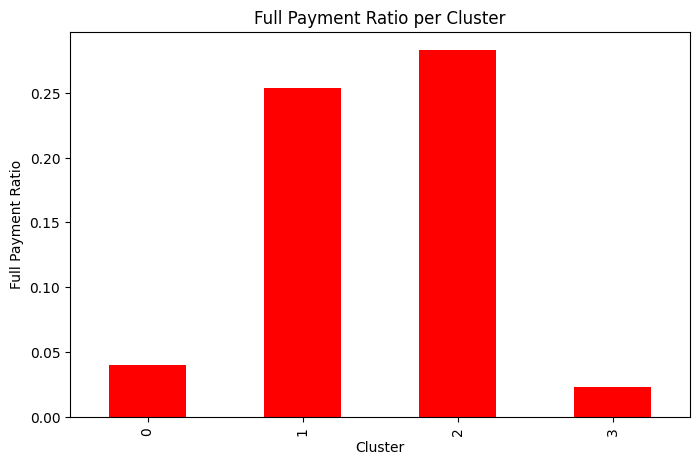

In [20]:
plt.figure(figsize=(8,5))
cluster_profile['PRC_FULL_PAYMENT'].plot(kind='bar', color='red')
plt.title("Full Payment Ratio per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Full Payment Ratio")
plt.show()

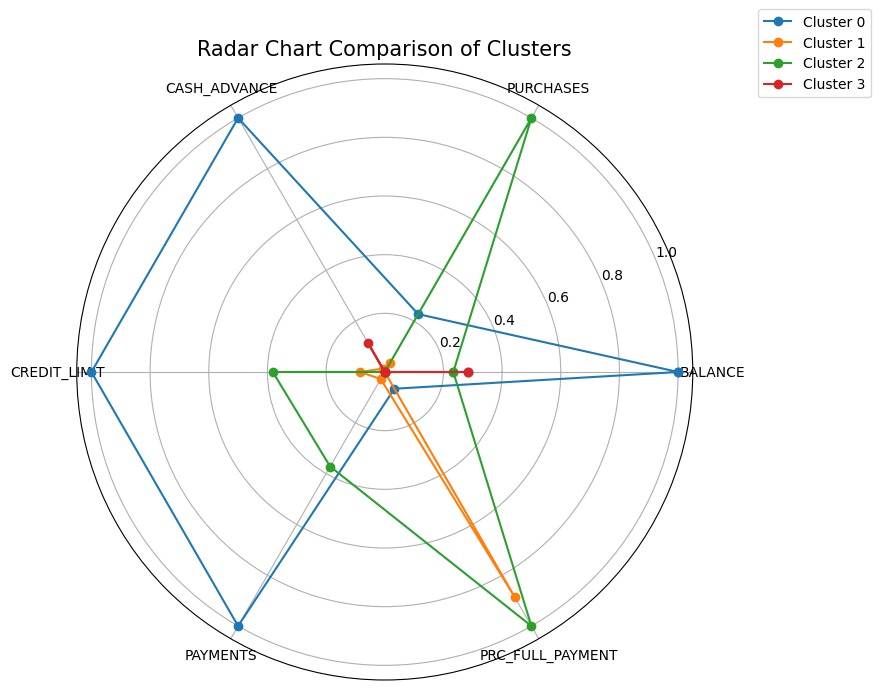

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select features for radar chart
features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']
    
# Take values from cluster_profile
data = cluster_profile[features]

# Normalize the values (so everything fits nicely on radar)
data_norm = (data - data.min()) / (data.max() - data.min())

# Number of variables
num_vars = len(features)

# Calculate angles for the radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]   # complete the circle

# Start plot
plt.figure(figsize=(8, 8))

# Plot each cluster
for i in range(len(data_norm)):
    values = data_norm.iloc[i].tolist()
    values += values[:1]  # complete loop

    plt.polar(angles, values, marker='o', label=f'Cluster {i}')

# Add labels
plt.xticks(angles[:-1], features)
plt.title("Radar Chart Comparison of Clusters", size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

| Cluster | Type of Customer                     | Behavior Summary                                             |
| ------- | ------------------------------------ | ------------------------------------------------------------ |
| **0**   | Heavy Cash Advance Users             | High balance, very high cash advance, medium purchases       |
| **1**   | Low Spenders                         | Low balance, low credit limit, low purchases, safe customers |
| **2**   | High Spenders                        | High purchases, frequent shoppers, best customer group       |
| **3**   | Low Spending + Moderate Cash Advance | Medium balance, low purchases, occasional cash advance       |
